## Databeskrivning: ObesityDataSet_raw_and_data_sinthetic.csv

Datasetet innehåller syntetiska uppgifter om livsstil, kostvanor och hälsa för olika individer.  
Syftet är att förutsäga personens viktklass (t.ex. Normal Weight, Overweight, Obesity Type I–III).

Varje rad i datasetet representerar en individ med följande attribut:

**Gender** beskriver personens kön (Male eller Female). 

**Age** anger ålder i år.

**Height** visar längden i meter och **Weight** vikten i kilogram.

**family_history_with_overweight** indikerar om det finns övervikt i familjen (yes eller no).  

**FAVC** anger om personen ofta äter kaloririk mat.  

**FCVC** (värden 1–3) visar hur ofta personen äter grönsaker: 1 = sällan, 2 = ibland, 3 = ofta.  

**NCP** anger antalet huvudmåltider per dag (1–4).  

**CAEC** beskriver mellanmålsvanor (no, Sometimes, Frequently, Always).  

**SMOKE** visar om personen röker (yes eller no).  

**CH2O** (värden 1–3) anger hur mycket vatten som konsumeras per dag: 1 = lite, 2 = måttligt, 3 = mycket. 

**SCC** visar om personen kontrollerar sitt kaloriintag.  

**FAF** (värden 0–3) anger fysisk aktivitet i timmar per vecka: 0 = ingen, 1 = låg, 2 = måttlig, 3 = hög. 

**TUE** (värden 0–2) visar tid framför skärm per dag.  

**CALC** beskriver alkoholkonsumtion (no, Sometimes, Frequently, Always).  

**MTRANS** visar huvudsakligt transportmedel (Public Transportation, Walking, Automobile, Motorbike eller Bike).  

Slutligen representerar **NObeyesdad** målvariabeln, dvs. personens viktklass, som kan vara:  
Insufficient Weight, Normal Weight, Overweight Level I–II, eller Obesity Type I–III.

---

### Syfte
Målet med projektet är att bygga en maskininlärningsmodell som förutsäger en persons viktklass baserat på deras livsstil, kostvanor och demografiska faktorer.


In [11]:
##  Dataförberedelse och förhandsgranskning

import pandas as pd

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print("Form:", df.shape)
print("\nKolumner:\n", df.columns.tolist())
print("\nFörsta raderna:\n", df.head())


Form: (2111, 17)

Kolumner:
 ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

Första raderna:
    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes

##  – Explorativ dataanalys (EDA) och Förbehandling
Syftet är att undersöka data, hitta mönster, relationer och förbereda data för modellträning.


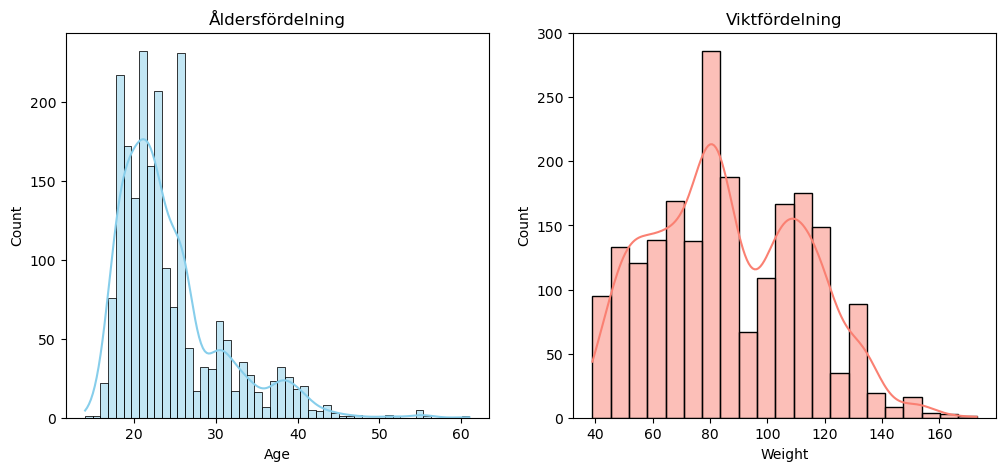

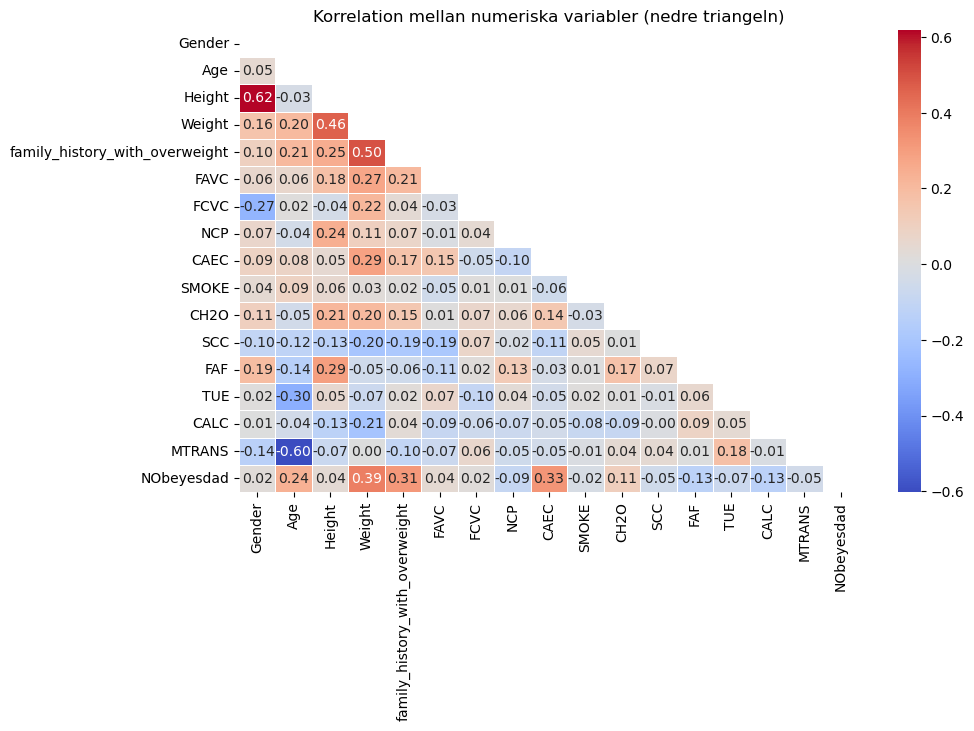

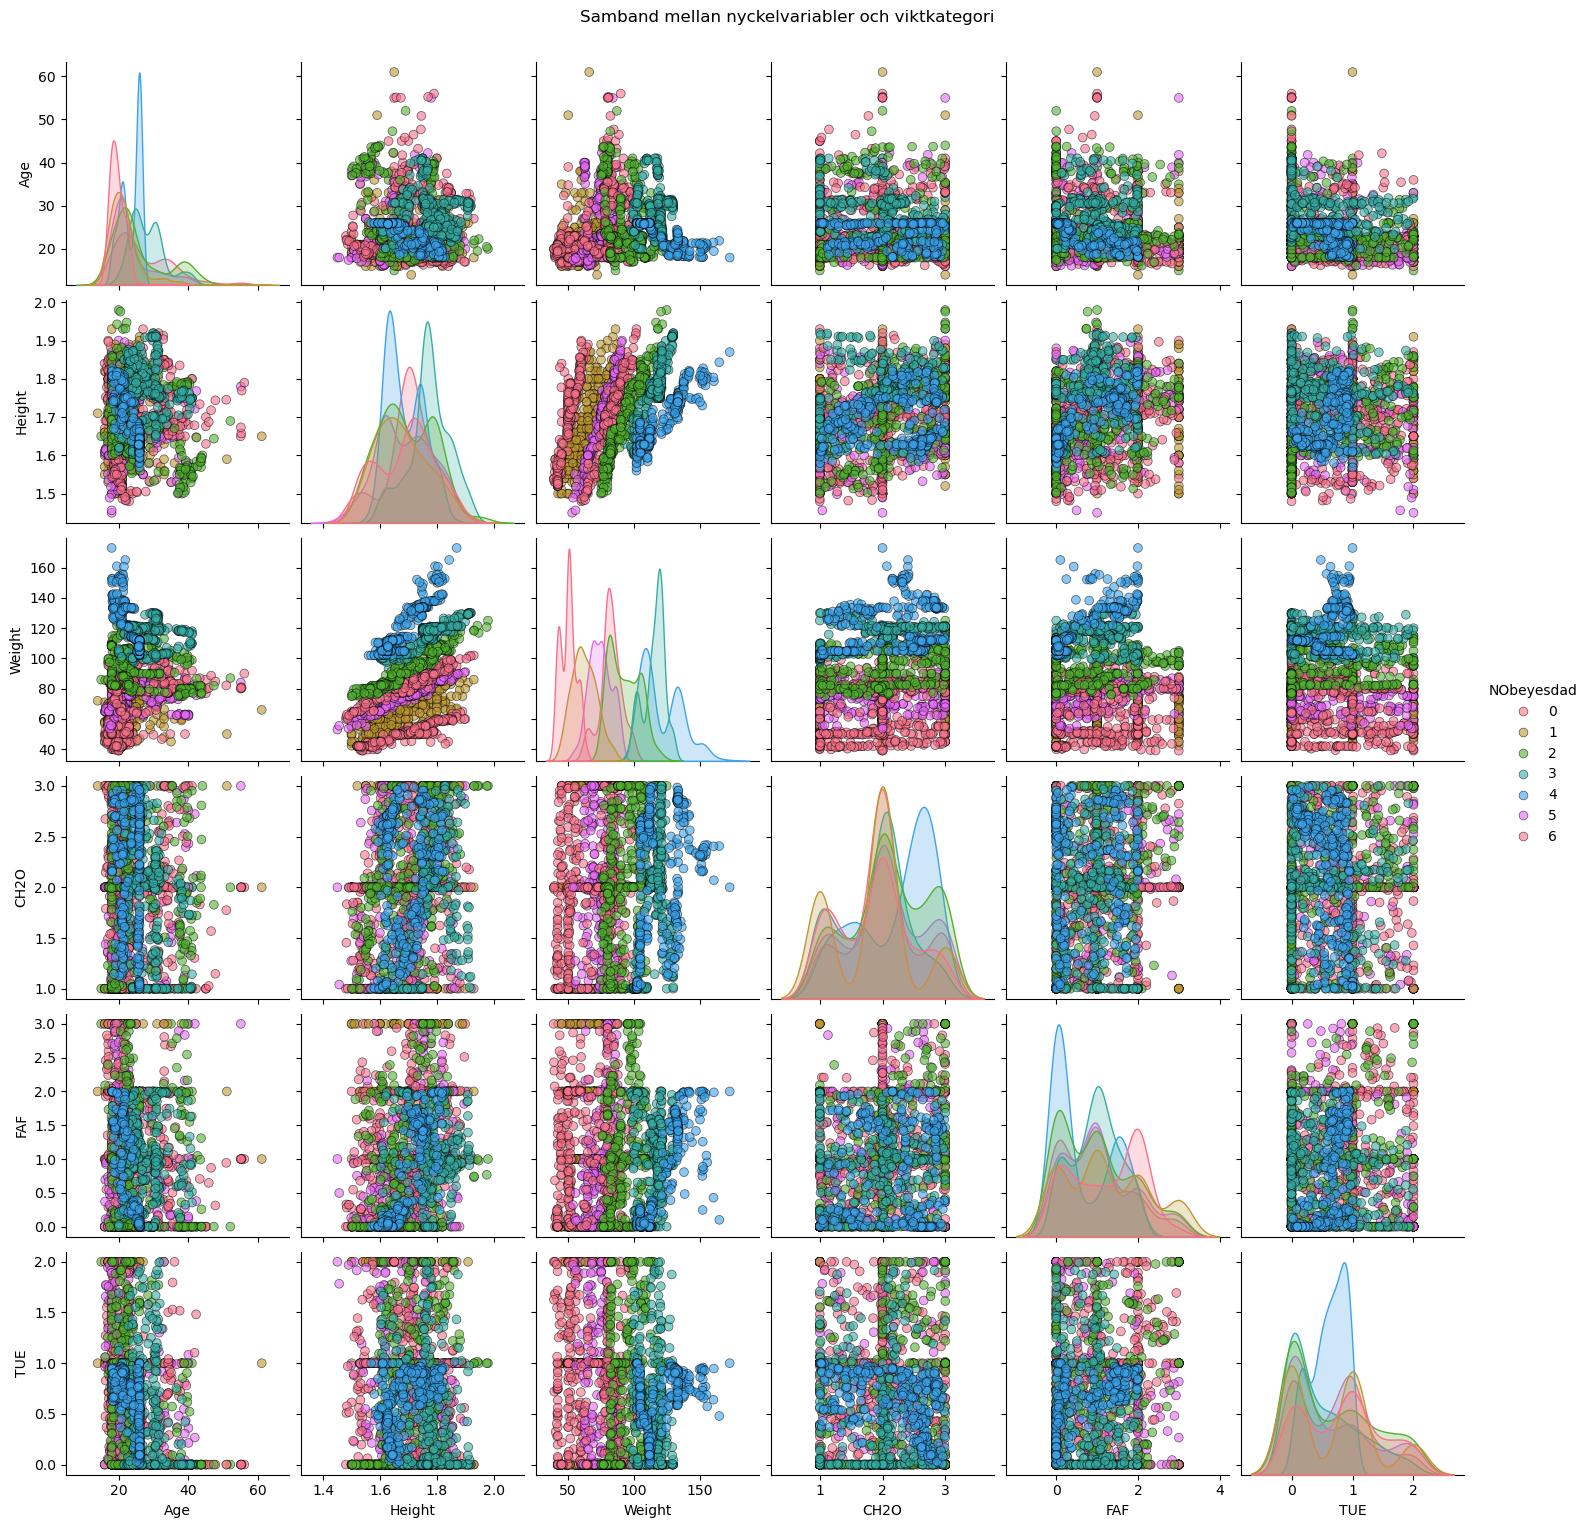


Saknade värden per kolumn:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Alla kategoriska kolumner har kodats till numeriska värden.

Förbehandling klar. Data redo för modellträning.
Träningsdata: (1688, 16)
Testdata: (423, 16)


In [7]:
# FAS 2 – Explorativ dataanalys (EDA) och Förbehandling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Histogram för ålder och vikt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title("Åldersfördelning")

plt.subplot(1,2,2)
sns.histplot(df['Weight'], kde=True, color='salmon')
plt.title("Viktfördelning")
plt.show()

# Korrelation mellan numeriska variabler (endast nedre triangeln)
corr = df.select_dtypes('number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10,6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Korrelation mellan numeriska variabler (nedre triangeln)")
plt.show()

# Pairplot baserat på viktkategori
sns.pairplot(df, vars=['Age','Height','Weight','CH2O','FAF','TUE'],
             hue='NObeyesdad', palette='husl', diag_kind='kde',
             plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})
plt.suptitle("Samband mellan nyckelvariabler och viktkategori", y=1.02)
plt.show()

# Kontroll av saknade värden
print("\nSaknade värden per kolumn:\n", df.isna().sum())

# LabelEncoding av kategoriska kolumner
le = LabelEncoder()
for col in df.select_dtypes('object').columns:
    df[col] = le.fit_transform(df[col])
print("\nAlla kategoriska kolumner har kodats till numeriska värden.")

# Train/Test-split
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalning av data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFörbehandling klar. Data redo för modellträning.")
print("Träningsdata:", X_train.shape)
print("Testdata:", X_test.shape)





## Modellval och metod

För att förutsäga viktklass valdes modellen **Gradient Boosting Classifier**.  
Denna algoritm bygger flera svaga besluts­träd (decision trees) i följd, där varje nytt träd förbättrar de tidigare genom att fokusera på fel som modellen tidigare gjort.  

Gradient Boosting används ofta när man vill uppnå **hög noggrannhet** och samtidigt kunna analysera **vilka variabler som har störst betydelse** (feature importance). 

I detta projekt jämfördes flera modeller (t.ex. Decision Tree, Random Forest och Logistic Regression), men Gradient Boosting gav bäst resultat vid träning och validering.

Fördelar med Gradient Boosting i detta sammanhang:
- Ger bra balans mellan bias och variance (minskar överanpassning).  
- Hanterar både numeriska och kategoriska data effektivt.  
- Möjliggör visualisering av vilka faktorer som mest påverkar viktklassen (t.ex. vikt, längd, fysisk aktivitet, matvanor).

---

### Modellträning och sparande

Efter träningen sparades den bästa modellen som **`models/basta_pipeline.pkl`** med hjälp av `joblib`. 

Även klassnamnen (etiketterna för målvariabeln `NObeyesdad`) sparades i **`models/klasser.pkl`**.  

Dessa filer används senare i Flask-API:t för att möjliggöra nya prediktioner i realtid.


## Feature Importance – Viktiga variabler i modellen

Efter att modellen tränats analyserades vilka faktorer som har störst påverkan på prediktionen av viktklass.  
Visualiseringen nedan visar varje variabels relativa betydelse (feature importance).

Resultatet visar att **Weight** och **Height** är de mest avgörande faktorerna för att bestämma viktklassen.  

Andra variabler som **FCVC** (hur ofta man äter grönsaker) och **FAVC** (om man ofta äter kaloririk mat) har också viss påverkan.  

Livsstilsfaktorer som fysisk aktivitet (**FAF**) och vattenkonsumtion (**CH2O**) bidrar i mindre grad.

Detta bekräftar att både fysiska och beteendemässiga faktorer spelar roll för att förutsäga övervikt och fetma.

---



=== Jämförelse mellan modeller ===
                 Modell  Accuracy  Precision  Recall  F1-score  R2-score
0  Logistisk regression     0.875      0.873   0.875     0.873     0.676
1          RandomForest     0.936      0.941   0.936     0.938     0.798
2      GradientBoosting     0.950      0.953   0.950     0.951     0.891
3               XGBoost     0.960      0.962   0.960     0.960     0.905


C:\Users\aliko\AppData\Local\Temp\ipykernel_18556\3417603531.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modell", y="Accuracy", data=results_df, palette="viridis")


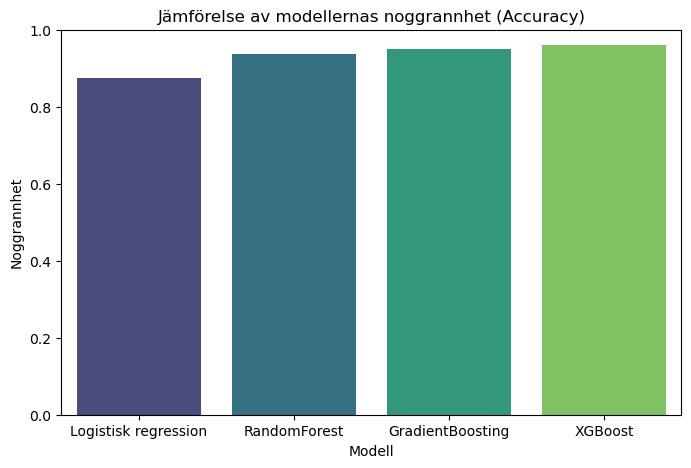


Bästa modellen: XGBoost
Klasser sparade korrekt: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

=== Utvärdering av bästa modell ===
Accuracy:  0.960
Precision: 0.962
Recall:    0.960
F1-score:  0.960
R2-score:  0.905


In [10]:
# ===== FAS 3–5: Pipeline-träning, utvärdering och export (Full VG-version) =====
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# === Läs in data ===
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# === LabelEncoder för målvariabeln ===
le = LabelEncoder()
df["NObeyesdad_enc"] = le.fit_transform(df["NObeyesdad"])

X_raw = df.drop(columns=["NObeyesdad", "NObeyesdad_enc"])
y_raw = df["NObeyesdad_enc"]

# === Train/Test-split ===
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# === Kolumner ===
num_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object']).columns.tolist()

# === Förbehandling ===
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# === Modeller ===
models = {
    "Logistisk regression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42
    )
}

# === Utvärdera alla modeller ===
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Modell": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3),
        "R2-score": round(r2, 3)
    })

# === Skapa tabell för jämförelse ===
results_df = pd.DataFrame(results)
print("\n=== Jämförelse mellan modeller ===")
print(results_df)

# === Diagram (bara accuracy) ===
plt.figure(figsize=(8,5))
sns.barplot(x="Modell", y="Accuracy", data=results_df, palette="viridis")
plt.ylim(0, 1)
plt.title("Jämförelse av modellernas noggrannhet (Accuracy)")
plt.ylabel("Noggrannhet")
plt.show()

# === Hitta bästa modell baserat på F1-score (eller Accuracy) ===
best_name = results_df.sort_values(by="F1-score", ascending=False).iloc[0]["Modell"]
best_model = Pipeline(steps=[("prep", preprocess), ("clf", models[best_name])])
best_model.fit(X_train_raw, y_train)

# === Spara bästa modell ===
joblib.dump(best_model, "models/basta_pipeline.pkl")
joblib.dump(list(le.classes_), "models/klasser.pkl")

print(f"\nBästa modellen: {best_name}")
print("Klasser sparade korrekt:", list(le.classes_))

# === Extra: utvärdera bästa modellen ===
y_pred_best = best_model.predict(X_test_raw)
acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted')
rec = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')
r2 = r2_score(y_test, y_pred_best)

print("\n=== Utvärdering av bästa modell ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"R2-score:  {r2:.3f}")


##  FAS 3–5: Pipeline-träning, utvärdering och export  
I detta steg byggs maskininlärningsmodellen. Flera algoritmer testades, där **Gradient Boosting Classifier** gav bäst resultat.  
Pipeline används för att kombinera databehandling (scaling, encoding) med modellträning i ett flöde.


In [ ]:
##  Sammanfattning

Projektet visade hur en maskininlärningsmodell kan användas för att förutsäga viktklass baserat på personens livsstil och kostvanor.  
Genom analysen framkom att **vikt och längd** är de mest avgörande faktorerna, men även vanor som **grönsaksintag, fysisk aktivitet och alkoholvanor** påverkar resultatet.

Modellen sparades som en `.pkl`-fil och integrerades i ett Flask-API som kan ta emot nya värden och returnera en förutsagd viktklass automatiskt.


In [14]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Läs in den bästa modellen (Gradient Boosting)
gb_model = joblib.load("models/basta_pipeline.pkl")

# Spara modell och klassnamn

joblib.dump(gb_model, "models/basta_pipeline.pkl")

# Här sparar vi de riktiga klasserna som modell förutspår
class_names = list(gb_model.classes_)
joblib.dump(class_names, "models/klasser.pkl")

print(" Modellen och klassnamnen har sparats!")


# Kontrollera om pipeline innehåller modell i slutet
print(gb_model)


 Modellen och klassnamnen har sparats!
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsampl

IndexError: index 17 is out of bounds for axis 0 with size 16

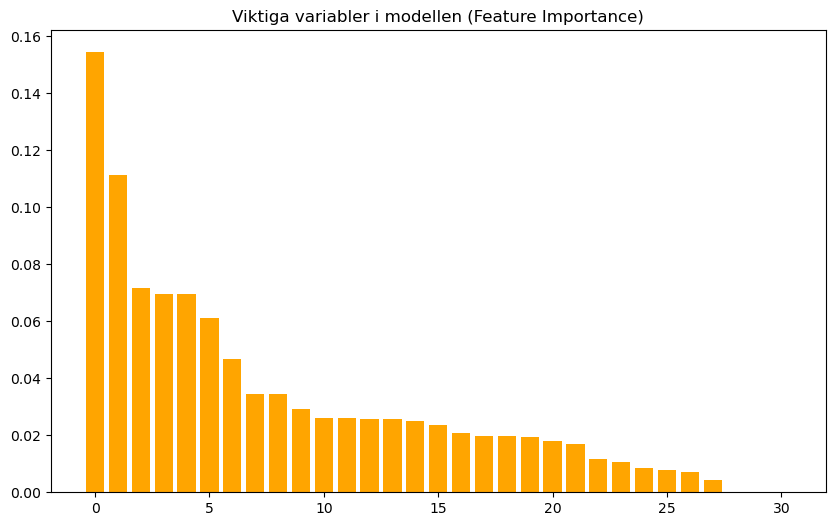

In [16]:
# --- Hämta feature names från pipeline ---
# Vi kollar vilka features som används i prep-steget
prep = gb_model.named_steps['prep']

# Namn på numeriska och kategoriska kolumner
num_features = prep.transformers_[0][2]
cat_features = prep.transformers_[1][2]

# Kombinera alla feature-namn
feature_names = list(num_features) + list(cat_features)

# --- Hämta feature importances ---
importances = gb_model.named_steps['clf'].feature_importances_

# Sortera efter vikt
indices = np.argsort(importances)[::-1]

# --- Plotta ---
plt.figure(figsize=(10,6))
plt.title("Viktiga variabler i modellen (Feature Importance)")
plt.bar(range(len(importances)), importances[indices], color="orange", align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.show()


In [1]:
import joblib
classes = joblib.load("models/klasser.pkl")
print(type(classes))
print(classes)


<class 'list'>
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [3]:
import joblib


gb_model = joblib.load("models/basta_pipeline.pkl")


class_names = list(gb_model.named_steps['clf'].classes_)


joblib.dump(class_names, "models/klasser.pkl")

print(" Nya klasser.pkl har skapats:")
print(class_names)


 Nya klasser.pkl har skapats:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [5]:
import joblib
import pandas as pd


gb_model = joblib.load("models/basta_pipeline.pkl")


data = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")


class_names = sorted(data["NObeyesdad"].unique())


joblib.dump(class_names, "models/klasser.pkl")

print(" Klasser sparade korrekt:")
print(class_names)


 Klasser sparade korrekt:
['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
